In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
df = pd.read_csv("customer_data_1million.csv")

In [3]:
df

,Age,Gender,AnnualIncome,SpendingScore,Website_Visits,Items_Added_To_Cart,Location,Purchased
0,39.0,0,40087.405754,18.594753,12.0,3.0,0,1
1,33.0,1,20000.000000,33.509525,23.0,6.0,0,1
2,41.0,1,20000.000000,30.757579,NaN,1.0,0,0
3,50.0,1,25309.552855,47.716943,12.0,1.0,0,1
4,32.0,1,21926.314401,NaN,18.0,4.0,0,1
...,...,...,...,...,...,...,...,...
999995,39.0,1,31008.096672,31.236913,16.0,2.0,2,1
999996,36.0,1,20000.000000,5.187374,17.0,2.0,2,1
999997,33.0,0,20000.000000,27.434187,16.0,3.0,1,1
999998,49.0,0,36619.467388,27.300285,16.0,3.0,0,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 8 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   Age                  950268 non-null   float64
 1   Gender               1000000 non-null  int64  
 2   AnnualIncome         950272 non-null   float64
 3   SpendingScore        949871 non-null   float64
 4   Website_Visits       950249 non-null   float64
 5   Items_Added_To_Cart  950114 non-null   float64
 6   Location             1000000 non-null  int64  
 7   Purchased            1000000 non-null  int64  
dtypes: float64(5), int64(3)
memory usage: 61.0 MB


In [5]:
df["Age"] = df["Age"].fillna(int(df["Age"].mean()))

In [6]:
df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])

In [7]:
df["AnnualIncome"] = df["AnnualIncome"].fillna(df["AnnualIncome"].mean())

In [8]:
df["SpendingScore"] = df["SpendingScore"].fillna(int(df["SpendingScore"].mean()))

In [9]:
df["Website_Visits"] = df["Website_Visits"].fillna(int(df["Website_Visits"].mean()))

In [10]:
df["Items_Added_To_Cart"] = df["Items_Added_To_Cart"].fillna(int(df["Items_Added_To_Cart"].mean()))

In [11]:
df["Location"] = df["Location"].fillna(df["Location"].mode()[0])

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 8 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   Age                  1000000 non-null  float64
 1   Gender               1000000 non-null  int64  
 2   AnnualIncome         1000000 non-null  float64
 3   SpendingScore        1000000 non-null  float64
 4   Website_Visits       1000000 non-null  float64
 5   Items_Added_To_Cart  1000000 non-null  float64
 6   Location             1000000 non-null  int64  
 7   Purchased            1000000 non-null  int64  
dtypes: float64(5), int64(3)
memory usage: 61.0 MB


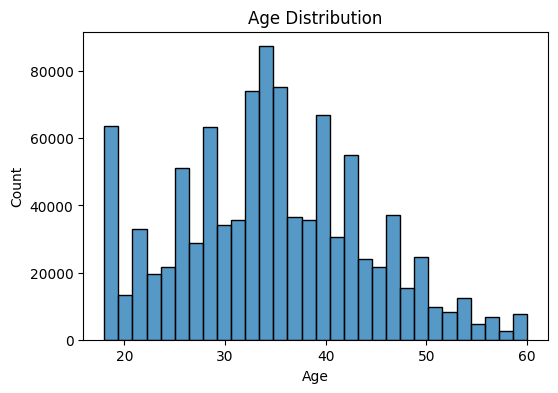

In [13]:
plt.figure(figsize=(6,4))
sns.histplot(df['Age'], bins=30)
plt.title("Age Distribution")
plt.show()

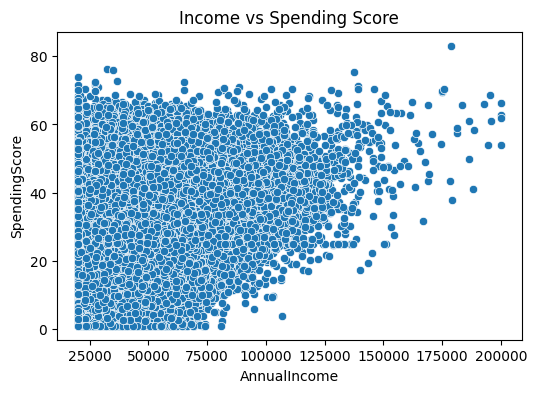

In [14]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='AnnualIncome', y='SpendingScore', data=df)
plt.title("Income vs Spending Score")
plt.show()

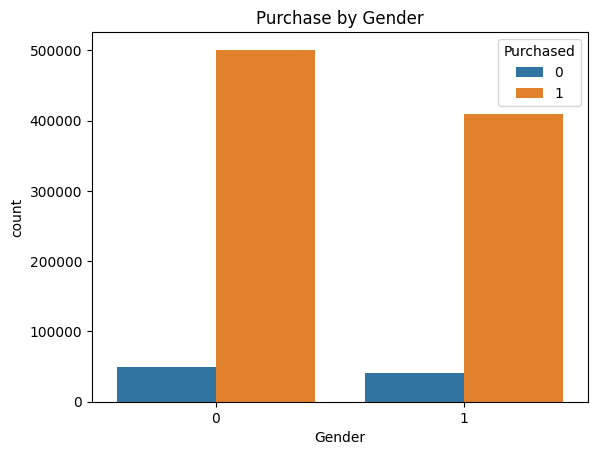

In [15]:
sns.countplot(x='Gender', hue='Purchased', data=df)
plt.title("Purchase by Gender")
plt.show()

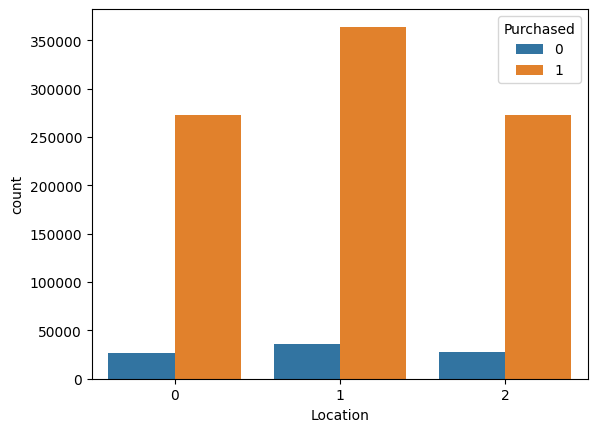

In [16]:
sns.countplot(x='Location', hue='Purchased', data=df)
plt.show()

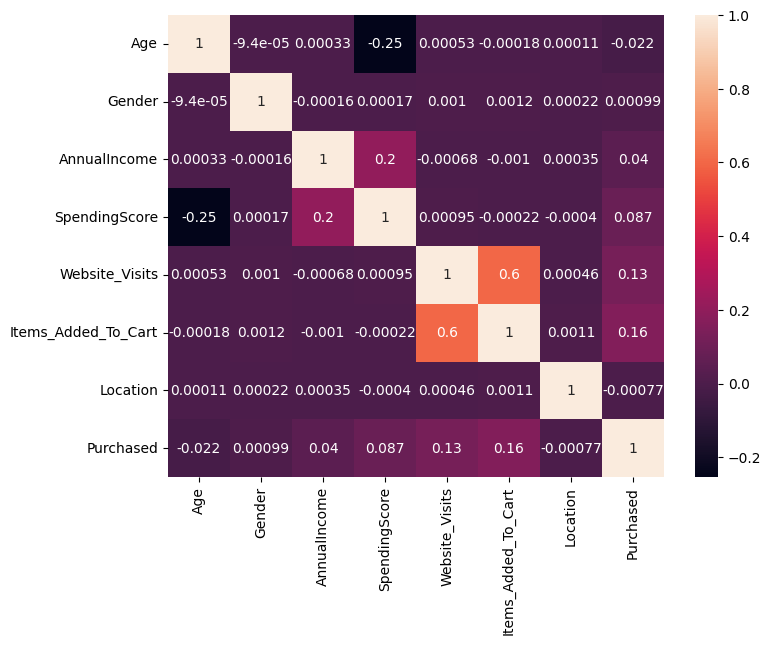

In [17]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

In [18]:
le = LabelEncoder()

df['Gender'] = le.fit_transform(df['Gender'])
df['Location'] = le.fit_transform(df['Location'])

In [19]:
df['Engagement'] = df['Website_Visits'] + df['Items_Added_To_Cart']
df['Spend_Ratio'] = df['SpendingScore'] / (df['AnnualIncome'] + 1)

In [20]:
X = df.drop('Purchased', axis=1)
y = df['Purchased']

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=2000)

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, pred_lr))

Logistic Regression Accuracy: 0.91061


In [24]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=10, metric='manhattan')

knn.fit(X_train, y_train)

pred_knn = knn.predict(X_test)

print("KNN Accuracy:",
      accuracy_score(y_test, pred_knn))

KNN Accuracy: 0.9071


In [25]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:",
      accuracy_score(y_test, pred_dt))

Decision Tree Accuracy: 0.909835


In [26]:
from sklearn.metrics import accuracy_score, recall_score

models = ['Logistic Regression','KNN','Decision Tree']

accuracy = [
    accuracy_score(y_test, pred_lr),
    accuracy_score(y_test, pred_knn),
    accuracy_score(y_test, pred_dt)
]

recall = [
    recall_score(y_test, pred_lr),
    recall_score(y_test, pred_knn),
    recall_score(y_test, pred_dt)
]

results = pd.DataFrame({
    'Model': models,
    'Accuracy': accuracy,
    'Recall': recall
})

print(results)

                 Model  Accuracy    Recall
0  Logistic Regression  0.910610  1.000000
1                  KNN  0.907100  0.994773
2        Decision Tree  0.909835  0.998819


In [27]:
df

,Age,Gender,AnnualIncome,SpendingScore,Website_Visits,Items_Added_To_Cart,Location,Purchased,Engagement,Spend_Ratio
0,39.0,0,40087.405754,18.594753,12.0,3.0,0,1,15.0,0.000464
1,33.0,1,20000.000000,33.509525,23.0,6.0,0,1,29.0,0.001675
2,41.0,1,20000.000000,30.757579,14.0,1.0,0,0,15.0,0.001538
3,50.0,1,25309.552855,47.716943,12.0,1.0,0,1,13.0,0.001885
4,32.0,1,21926.314401,25.000000,18.0,4.0,0,1,22.0,0.001140
...,...,...,...,...,...,...,...,...,...,...
999995,39.0,1,31008.096672,31.236913,16.0,2.0,2,1,18.0,0.001007
999996,36.0,1,20000.000000,5.187374,17.0,2.0,2,1,19.0,0.000259
999997,33.0,0,20000.000000,27.434187,16.0,3.0,1,1,19.0,0.001372
999998,49.0,0,36619.467388,27.300285,16.0,3.0,0,1,19.0,0.000745


In [28]:
df.to_csv("customer_data_1million_(2).csv", index=False)

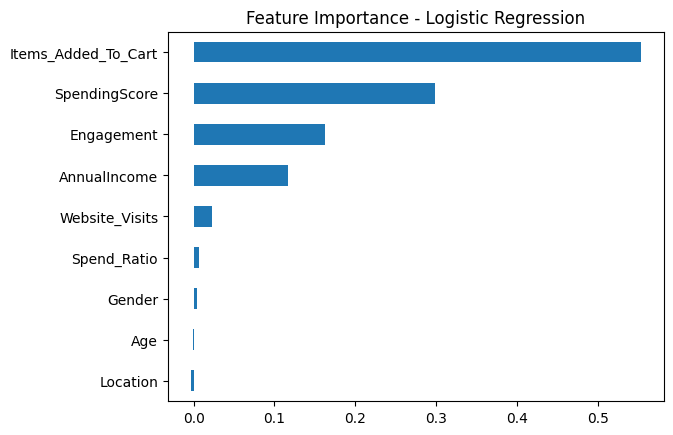

In [29]:
importance = pd.Series(lr.coef_[0], index=X.columns)

importance.sort_values().plot(kind='barh')
plt.title("Feature Importance - Logistic Regression")
plt.show()

In [30]:
results_lr = pd.DataFrame({
    "Actual": y_test,
    "Predicted": pred_lr
})

print(results_lr.head(10))

        Actual  Predicted
987231       1          1
79954        1          1
567130       1          1
500891       0          1
55399        1          1
135049       1          1
733378       1          1
732057       1          1
51333        1          1
731479       1          1


In [31]:
df['Predicted'] = lr.predict(scaler.transform(X))

In [32]:
df

,Age,Gender,AnnualIncome,SpendingScore,Website_Visits,Items_Added_To_Cart,Location,Purchased,Engagement,Spend_Ratio,Predicted
0,39.0,0,40087.405754,18.594753,12.0,3.0,0,1,15.0,0.000464,1
1,33.0,1,20000.000000,33.509525,23.0,6.0,0,1,29.0,0.001675,1
2,41.0,1,20000.000000,30.757579,14.0,1.0,0,0,15.0,0.001538,1
3,50.0,1,25309.552855,47.716943,12.0,1.0,0,1,13.0,0.001885,1
4,32.0,1,21926.314401,25.000000,18.0,4.0,0,1,22.0,0.001140,1
...,...,...,...,...,...,...,...,...,...,...,...
999995,39.0,1,31008.096672,31.236913,16.0,2.0,2,1,18.0,0.001007,1
999996,36.0,1,20000.000000,5.187374,17.0,2.0,2,1,19.0,0.000259,1
999997,33.0,0,20000.000000,27.434187,16.0,3.0,1,1,19.0,0.001372,1
999998,49.0,0,36619.467388,27.300285,16.0,3.0,0,1,19.0,0.000745,1
